---

# Fetch & Process Audio Corpus

> Downloads geotagged audio from Freesound, processes it into fixed-length
> 1-second clips, and saves everything needed for training.

**Outputs:**
- `.cache/audio/*.mp3` — raw downloads
- `.cache/data.json` — filename → geotag mapping
- `.cache/mappings.csv` — processed paths + normalized lat/lng
- `.cache/audio.npy` — numpy array of all processed clips (N, 44100)

---

In [2]:
import os
import json
import requests
import numpy as np
import pandas as pd
import librosa
import freesound
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

CACHE_DIR = os.path.join('..', '.cache')
AUDIO_DIR = os.path.join(CACHE_DIR, 'audio')
os.makedirs(AUDIO_DIR, exist_ok=True)

SAMPLE_RATE = 44100
NUM_SAMPLES = 5000

## 1. Fetch from Freesound

In [2]:
load_dotenv()

client = freesound.FreesoundClient()
client.set_token(os.getenv('FREESOUND_API_KEY'))

In [3]:
def download_audio(url, filename):
    resp = requests.get(url)
    with open(os.path.join(AUDIO_DIR, filename), 'wb') as f:
        f.write(resp.content)

In [4]:
def fetch_corpus(num_samples=5000):
    url = 'https://freesound.org/apiv2/search/text/'
    params = {
        'filter': 'is_geotagged:1%20duration:[1 TO 60]',
        'fields': 'geotag,tags,id,previews',
        'page_size': 150,
        'token': os.getenv('FREESOUND_API_KEY'),
    }

    tasks = []
    mappings = {}
    response = requests.get(url, params=params).json()
    count = 0

    pbar = tqdm(total=num_samples, desc='Fetching API')
    while response.get('next') is not None and count < num_samples:
        for result in response['results']:
            audio_url = result['previews']['preview-hq-mp3']
            filename = f"{result['id']}.mp3"
            geotag = result.get('geotag')
            if geotag:
                mappings[filename] = geotag
                tasks.append((audio_url, filename))
            count += 1
            pbar.update(1)
            if count >= num_samples:
                break
        if count < num_samples and response.get('next'):
            response = requests.get(url=response['next'], params=params).json()
    pbar.close()

    pbar = tqdm(total=len(tasks), desc='Downloading')
    with ThreadPoolExecutor(max_workers=16) as executor:
        futures = {executor.submit(download_audio, url, name): name for url, name in tasks}
        for future in as_completed(futures):
            future.result()
            pbar.update(1)
    pbar.close()

    with open(os.path.join(CACHE_DIR, 'data.json'), 'w') as f:
        json.dump(mappings, f, indent=2)

    print(f'Downloaded {len(tasks)} files')
    return mappings

In [5]:
mappings = fetch_corpus(NUM_SAMPLES)

Fetching API:   0%|          | 0/5000 [00:00<?, ?it/s]

Downloading:   0%|          | 0/5000 [00:00<?, ?it/s]

Downloaded 5000 files


## 2. Process geotags

In [3]:
with open(os.path.join(CACHE_DIR, 'data.json')) as f:
    data = json.load(f)

rows = []
for filename, geotag in data.items():
    lat, lng = geotag.split()
    rows.append({
        'path': os.path.join(AUDIO_DIR, filename),
        'lat': float(lat) / 90.0,
        'lng': float(lng) / 180.0,
    })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(CACHE_DIR, 'mappings.csv'), index=False)
print(f'{len(df)} samples with valid geotags')
df.head()

5000 samples with valid geotags


,path,lat,lng
0,../.cache/audio/33716.mp3,0.372981,-0.566150
1,../.cache/audio/33531.mp3,0.457793,0.051874
2,../.cache/audio/33530.mp3,0.457793,0.051874
3,../.cache/audio/33529.mp3,0.457793,0.051874
4,../.cache/audio/33521.mp3,0.583121,-0.011643


## 3. Process audio

In [4]:
def compress(audio, threshold=0.2, ratio=4):
    compressed = np.copy(audio)
    mask = np.abs(compressed) > threshold
    compressed[mask] = np.sign(compressed[mask]) * (
        threshold + (np.abs(compressed[mask]) - threshold) / ratio
    )
    return compressed


def normalize(audio):
    peak = np.max(np.abs(audio))
    if peak > 0:
        return audio / peak
    return audio

In [5]:
clips = []

for i, row in tqdm(df.iterrows(), total=len(df), desc='Processing audio'):
    try:
        y, sr = librosa.load(row['path'], sr=SAMPLE_RATE)

        if y.shape[0] < SAMPLE_RATE:
            y = np.pad(y, (0, max(0, SAMPLE_RATE - len(y))), mode='constant')
        else:
            y = compress(y)
            harmonic, _ = librosa.effects.hpss(y)
            rms = librosa.feature.rms(y=harmonic[:-SAMPLE_RATE])[0]
            max_harm = librosa.frames_to_time(np.argmax(rms), sr=sr)
            y = y[int(max_harm * sr): int(max_harm * sr) + SAMPLE_RATE]

        y = normalize(y)
        clips.append(y)
    except Exception as e:
        pass

audio = np.array(clips, dtype=np.float32)
np.save(os.path.join(CACHE_DIR, 'audio.npy'), audio)
print(f'Saved {audio.shape} to audio.npy')

Processing audio:   0%|          | 0/5000 [00:00<?, ?it/s]

Saved (5000, 44100) to audio.npy


## 4. Distribution analysis

In [6]:
import matplotlib.pyplot as plt
import plotly.express as px
import reverse_geocoder as rg
import pycountry

In [7]:
geo_df = pd.read_csv(os.path.join(CACHE_DIR, 'mappings.csv'))
geo_df['lat'] = geo_df['lat'] * 90.0
geo_df['lng'] = geo_df['lng'] * 180.0
geo_df.head()

,path,lat,lng
0,../.cache/audio/33716.mp3,33.568247,-101.906927
1,../.cache/audio/33531.mp3,41.201394,9.337349
2,../.cache/audio/33530.mp3,41.201394,9.337349
3,../.cache/audio/33529.mp3,41.201394,9.337349
4,../.cache/audio/33521.mp3,52.480925,-2.095728


### Scatter plot

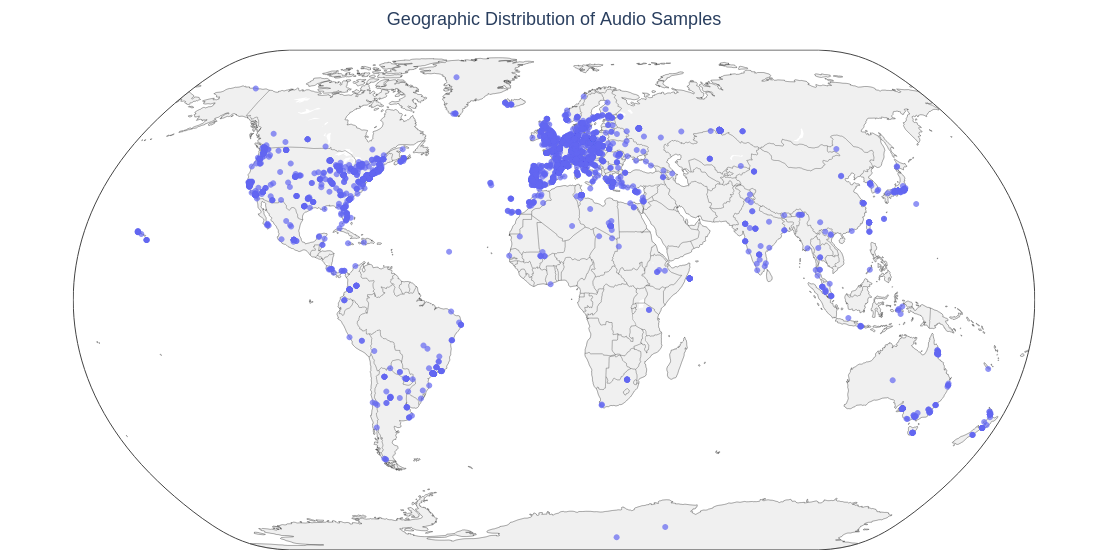

In [8]:
fig = px.scatter_geo(
    geo_df, lat='lat', lon='lng',
    title='Geographic Distribution of Audio Samples',
    opacity=0.7,
    color_discrete_sequence=['#6366f1'],
)
fig.update_geos(
    showcountries=True, countrycolor='rgba(0,0,0,0.15)',
    showcoastlines=True, coastlinecolor='rgba(0,0,0,0.2)',
    showland=True, landcolor='#f0f0f0',
    projection_type='natural earth',
    bgcolor='white',
)
fig.update_layout(title_x=0.5, title_font_size=18, margin=dict(l=0, r=0, t=50, b=0), height=550)
fig.show()

### Choropleth plot

In [9]:
countries = []
for _, row in tqdm(geo_df.iterrows(), total=len(geo_df), desc='Fetching countries'):
    location = rg.search([row['lat'], row['lng']])
    cc = location[0].get('cc')
    country = pycountry.countries.get(alpha_2=cc).name
    countries.append(country)

Fetching countries:   0%|          | 0/5000 [00:00<?, ?it/s]

Loading formatted geocoded file...


In [10]:
country_counts = pd.Series(countries).value_counts().reset_index()
country_counts.columns = ['country', 'count']
country_counts['iso_alpha'] = country_counts['country'].apply(lambda c: pycountry.countries.get(name=c).alpha_3)
country_counts.to_csv(os.path.join(CACHE_DIR, 'distribution.csv'), index=False)
country_counts.head(10)

,country,count,iso_alpha
0,Spain,1303,ESP
1,United States,701,USA
2,France,429,FRA
3,Germany,398,DEU
4,United Kingdom,308,GBR
5,Poland,218,POL
6,Netherlands,151,NLD
7,Italy,126,ITA
8,Russian Federation,108,RUS
9,Portugal,104,PRT


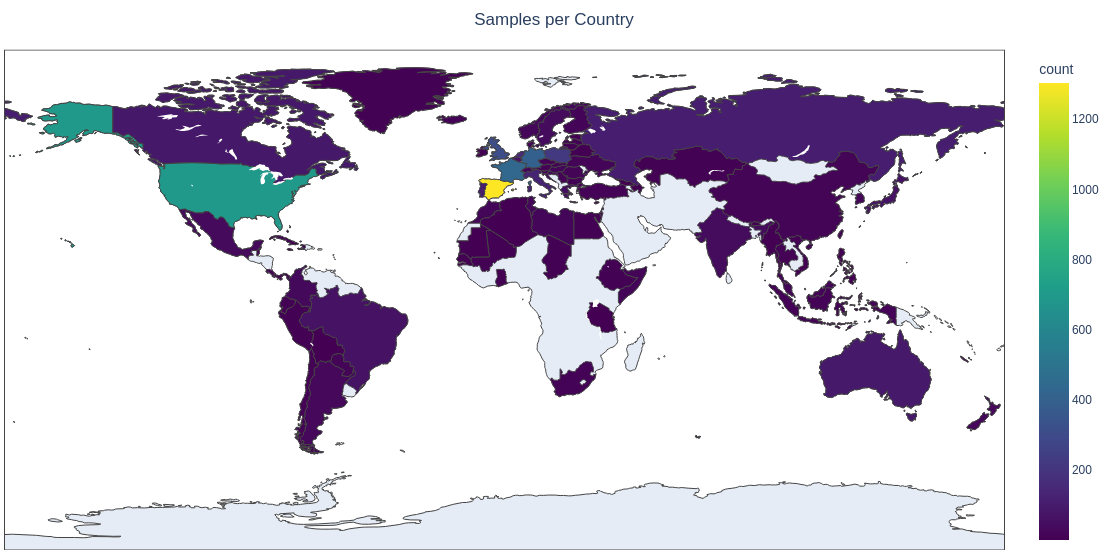

In [11]:
fig = px.choropleth(
    country_counts,
    locations='iso_alpha',
    color='count',
    hover_name='country',
    color_continuous_scale='viridis',
    title='Samples per Country',
)
fig.update_layout(title_x=0.5, margin=dict(l=0, r=0, t=50, b=0), height=550)
fig.show()